# Testing Code for Optimizers

We will compare SOAP and AdamW

In [118]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW, Adam

from tqdm import tqdm

from experimental_optimizers.soap_mods import SOAP

Let's generate a simple 1D regression problem

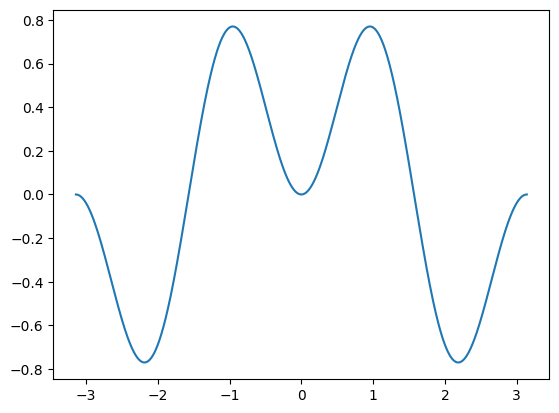

In [119]:
x = np.linspace(-np.pi, np.pi, 1000)
y = np.sin(x)*np.sin(2*x)
plt.plot(x, y)
class LinearNN(nn.Module):
    def __init__(self, hidden_size: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32, bias=True),
            nn.ReLU(),
            nn.Linear(32, hidden_size, bias=True),
            nn.ReLU(),
            nn.Linear(hidden_size, 1, bias=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

Create the training and testing datasets, then create a training loop

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train.reshape(-1, 1))
x_test = scaler.transform(x_test.reshape(-1, 1))

X_train = torch.from_numpy(x_train).float()
Y_train = torch.from_numpy(y_train).float().unsqueeze(1)
X_test = torch.from_numpy(x_test).float()
Y_test = torch.from_numpy(y_test).float().unsqueeze(1)

Set up of the data loader, loss and optimizers

In [121]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train, Y_train = X_train.to(device), Y_train.to(device)
X_test,  Y_test  = X_test.to(device),  Y_test.to(device)

In [122]:
loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=64, shuffle=True)
criterion = nn.MSELoss()

optimizer_configs = {
    "SOAP_no_projection":   lambda p: SOAP(p, lr=0.003, betas = (0.99, 0.999), precondition_1d=True, projection=False, precondition_frequency=100),
    "SOAP_with_projection": lambda p: SOAP(p, lr=0.003, betas = (0.99, 0.999), precondition_1d=True, projection=True, precondition_frequency=10),
    "AdamW":                 lambda p: AdamW(p, lr=0.001, betas = (0.9, 0.999), weight_decay=0.01)
}


epochs = 500
training_repetitions = 5

In [123]:
def reset_weights(m, seed):
    if hasattr(m, 'reset_parameters'):
        torch.manual_seed(seed)
        torch.nn.init.xavier_normal_(m.weight)
        torch.nn.init.zeros_(m.bias)

## Training

In [124]:
results = {}

for i, opt_name in enumerate(optimizer_configs):
    model = LinearNN().to(device)
    opt_fun = optimizer_configs[opt_name]
    optimizer = opt_fun(model.parameters())
    print(f"Training with optimizer {opt_name}...")
    loss_history = np.zeros((epochs,training_repetitions))
    
    for rep in range(training_repetitions):
        model.apply(lambda m: reset_weights(m, seed=rep+678))  # reset weights with different seed for each repetition

        pbar = tqdm(range(epochs), desc="Training",)
        for epoch in pbar:
            epoch_loss = 0.0
            for x_batch, y_batch in loader:
                optimizer.zero_grad()
                y_pred = model(x_batch)
                loss = criterion(y_pred, y_batch)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * len(x_batch)

            epoch_loss /= len(X_train)
            loss_history[epoch, rep] = epoch_loss  # save loss for this epoch
            if (epoch) % 10 == 0:
                pbar.set_postfix(mse=f"{epoch_loss:.6f}")
    results[opt_name] = {"model": model, "loss_history_avg": np.mean(loss_history, axis=1), "loss_history_std": np.std(loss_history, axis=1)}


Training with optimizer SOAP_no_projection...


Training: 100%|██████████| 500/500 [00:09<00:00, 53.33it/s, mse=0.000286]


Training with optimizer SOAP_with_projection...


Training: 100%|██████████| 500/500 [00:09<00:00, 52.76it/s, mse=0.000161]


Training with optimizer AdamW...


Training: 100%|██████████| 500/500 [00:03<00:00, 129.64it/s, mse=0.000282]


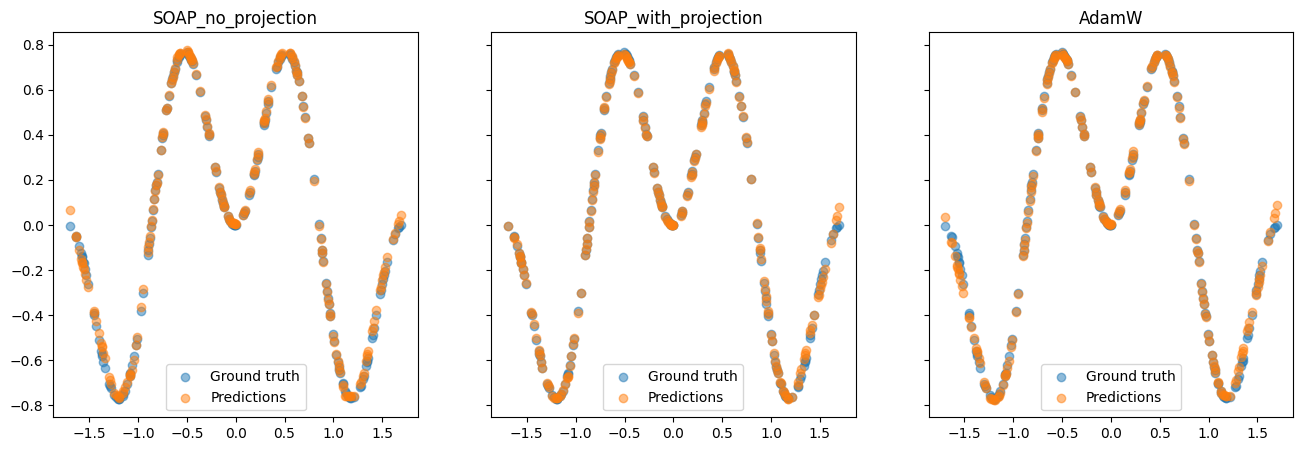

In [125]:
model.eval()

heigth = 5
width = len(optimizer_configs) * heigth + 1
fig, axs = plt.subplots(1, len(optimizer_configs), figsize=(width, heigth), sharey=True)

for i, opt_name in enumerate(optimizer_configs):
    with torch.no_grad():
        mod_to_plot = results[opt_name]["model"]
        preds = mod_to_plot(X_test).squeeze(1).cpu().detach().numpy()

    axs[i].scatter(x_test, y_test, label="Ground truth", alpha=0.5)
    axs[i].scatter(x_test, preds, label="Predictions", alpha=0.5)
    axs[i].set_title(f"{opt_name}")
    axs[i].legend()

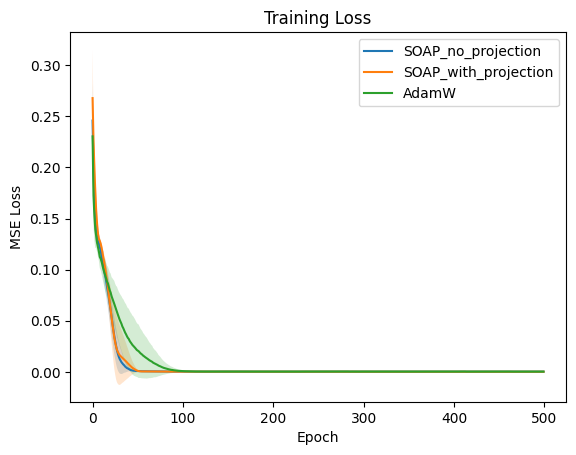

In [126]:
fig, ax = plt.subplots(1, 1)
for i, opt_name in enumerate(optimizer_configs):
    ax.plot(results[opt_name]["loss_history_avg"], label=opt_name)
    ax.fill_between(range(epochs),                    
                    results[opt_name]["loss_history_avg"] - results[opt_name]["loss_history_std"],
                    results[opt_name]["loss_history_avg"] + results[opt_name]["loss_history_std"], alpha=0.2)
ax.set_title("Training Loss")
# ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()